In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/creditcardfraud/creditcard.csv


Text(0.5, 1.0, 'Class Imbalance')

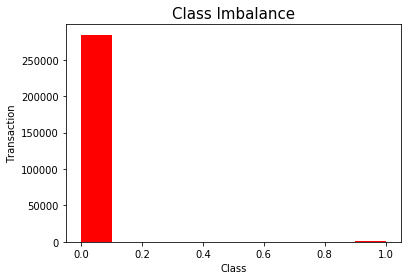

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')
plt.hist(data['Class'], color='red')
plt.xlabel('Class')
plt.ylabel('Transaction')
plt.title('Class Imbalance', fontsize=15)

In [3]:
pc_fraud = len(data.loc[data['Class'] == 1].values)/len(data.loc[data['Class'] == 0].values)
print(pc_fraud*100)
print(data.head())

0.17304750013189596
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26 

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from collections import Counter

# Original dataset
x = data.drop('Class', axis=1).values
y = data['Class'].values
scaler = MinMaxScaler()
scaler.fit(x)
x = scaler.transform(x)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=0)

print('Sampled train dataset shape %s' % Counter(ytrain))
print('Sampled validation dataset shape %s' % Counter(ytest))

Sampled train dataset shape Counter({0: 227454, 1: 391})
Sampled validation dataset shape Counter({0: 56861, 1: 101})


In [5]:
import torch

bs =100

#creating torch dataset and loader using original dataset. 
#to use resampled dataset, replace ex. xtrain with xtrain_over etc.
train_ds = torch.utils.data.TensorDataset(torch.tensor(xtrain).float(), torch.tensor(ytrain).float())
valid_ds = torch.utils.data.TensorDataset(torch.tensor(xtest).float(), torch.tensor(ytest).float())

train_dl = torch.utils.data.DataLoader(train_ds, batch_size=bs)
valid_dl = torch.utils.data.DataLoader(valid_ds, batch_size=bs)

In [6]:
#network class 2-hidden layer model
class Classifier(torch.nn.Module):
    def __init__(self, n_input=10, n_hidden = 20, n_output = 1,drop_prob=0.5):
        super().__init__()
        self.extractor1 = torch.nn.Linear(n_input, n_hidden)
        self.extractor2 = torch.nn.Linear(n_hidden, n_hidden)
        self.relu = torch.nn.ReLU()
        self.drop_out = torch.nn.Dropout(drop_prob)
        self.classifier = torch.nn.Linear(n_hidden, n_output)

    def forward(self, xb):
        x = self.relu(self.extractor1(xb))
        x = self.relu(self.extractor2(x))
        x = self.drop_out(x)
        return self.classifier(x).squeeze()


In [7]:
def loss_batch(model, loss_func, xb, yb, opt=None):
    loss = loss_func(model(xb), yb)

    if opt is not None:
        loss.backward()
        opt.step()
        opt.zero_grad()

    return loss.item(), len(xb)

In [8]:
#training the network
def train(epochs, model, loss_func, opt, train_dl, valid_dl):
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_dl:
            loss_batch(model, loss_func, xb, yb, opt)

        model.eval()
        with torch.no_grad():
            losses, nums = zip(
                *[loss_batch(model, loss_func, xb, yb) for xb, yb in valid_dl]
            )
        val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)

        print(epoch, val_loss)


In [9]:
#network setting
n_input = xtrain.shape[1]
n_output = 1
n_hidden = 15

model = Classifier(n_input=n_input,n_hidden=n_hidden,n_output=n_output,drop_prob=0.2)

lr = 0.001

#for orignal dataset, I use pos_weight.
pos_weight = torch.tensor([5])
opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
loss_func = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

n_epoch = 200

In [10]:
train(n_epoch,model,loss_func,opt,train_dl,valid_dl)
model.eval()


0 0.04748859682572719
1 0.04675509703171405
2 0.045905731660325515
3 0.044963012748793524
4 0.04379758458070637
5 0.04237205800309812
6 0.04047189578202396
7 0.038324079268751365
8 0.03566697909740698
9 0.0330885060849212
10 0.030451120220418758
11 0.02783313949523513
12 0.02546668692180581
13 0.02348836656101133
14 0.021750005291316286
15 0.020284302542417417
16 0.018746095137444484
17 0.017491064429898093
18 0.016559365548883976
19 0.01546794570719419
20 0.014752640593246958
21 0.014079354159686162
22 0.013519780446370533
23 0.013223268658860476
24 0.01278956133783507
25 0.012596199097529511
26 0.012390513846859491
27 0.012173662733441355
28 0.011965383277212048
29 0.01181746836211777
30 0.011755159139800487
31 0.011513756703911762
32 0.011510615408575757
33 0.011363118305410569
34 0.011245580152826071
35 0.011315734571895036
36 0.011128698563141037
37 0.01119719308166031
38 0.01106115810778562
39 0.011082667528019502
40 0.010976157229989543
41 0.01088816450414907
42 0.01086148698087

Classifier(
  (extractor1): Linear(in_features=30, out_features=15, bias=True)
  (extractor2): Linear(in_features=15, out_features=15, bias=True)
  (relu): ReLU()
  (drop_out): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=15, out_features=1, bias=True)
)

In [11]:
from sklearn import metrics
ypred = model(torch.tensor(xtest).float()).detach().numpy()

ypred [ypred>=0.5] =1.0
ypred [ypred<0.5] =0.0
print('Confusion matrix: {}'. format(metrics.confusion_matrix(ytest, ypred)))
print('AUPRC score: {}'. format(metrics.average_precision_score(ytest, ypred)))
print('AUROC score: {}'.format(metrics.roc_auc_score(ytest, ypred)))
print('Accuracy score: {}'.format(metrics.accuracy_score(ytest, ypred)))
print(metrics.classification_report(ytest, ypred))

Confusion matrix: [[56844    17]
 [   18    83]]
AUPRC score: 0.6823952080612365
AUROC score: 0.910741601762575
Accuracy score: 0.999385555282469
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56861
           1       0.83      0.82      0.83       101

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

